<a href="https://colab.research.google.com/github/dorcasojo/AVCAD-/blob/main/Exercise_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import pairwise_distances
from scipy.spatial.distance import pdist, squareform

In [6]:
# Load your dataset (adjust filename if needed)
df = pd.read_csv('/content/EFIplus_medit.csv', sep=';')

# Filter for the 4 basins
basins = ['Douro', 'Tejo', 'Mondego', 'Minho']
df_filtered = df[df['Catchment_name'].isin(basins)].copy()

print(df_filtered.shape)
print(df_filtered['Catchment_name'].value_counts())

(1703, 164)
Catchment_name
Minho      707
Tejo       509
Douro      401
Mondego     86
Name: count, dtype: int64




##Select Quantitative Environmental Variables##




In [7]:
# Drop non-numeric / identifier columns — adjust this list to your dataset
cols_to_drop = ['Catchment_name', 'Site', 'Site_code']  # adjust as needed

env_vars = df_filtered.select_dtypes(include=[np.number]).columns.tolist()
print("Environmental variables:", env_vars)

X = df_filtered[env_vars].dropna()
groups = df_filtered.loc[X.index, 'Catchment_name']

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Environmental variables: ['Latitude', 'Longitude', 'Galiza', 'Subsample', 'Calib_EFI_Medit', 'Calib_connect', 'Calib_hydrol', 'Calib_morphol', 'Calib_wqual', 'Geomorph1', 'Geomorph2', 'Geomorph3', 'Altitude', 'Actual_river_slope', 'Natural_sediment', 'Elevation_mean_catch', 'prec_ann_catch', 'temp_ann', 'temp_jan', 'temp_jul', 'Barriers_catchment_down', 'Barriers_river_segment_up', 'Barriers_river_segment_down', 'Barriers_number_river_segment_up', 'Barriers_number_river_segment_down', 'Barriers_distance_river_segment_up', 'Barriers_distance_river_segment_down', 'Impoundment', 'Hydropeaking', 'Water_abstraction', 'Hydro_mod', 'Temperature_impact', 'Velocity_increase', 'Reservoir_flushing', 'Sedimentation', 'Channelisation', 'Cross_sec', 'Instream_habitat', 'Riparian_vegetation', 'Embankment', 'Floodprotection', 'Floodplain', 'Toxic_substances', 'Acidification', 'Water_quality_index', 'Eutrophication', 'Organic_pollution', 'Organic_siltation', 'Sum of Run1_number_all', 'Total_sp', 'Abram

##Prompt: Run a PCA on the environmental variables and make a biplot showing site scores and variable arrows, colored by catchment name.

PC1: 18.4%  |  PC2: 7.2%


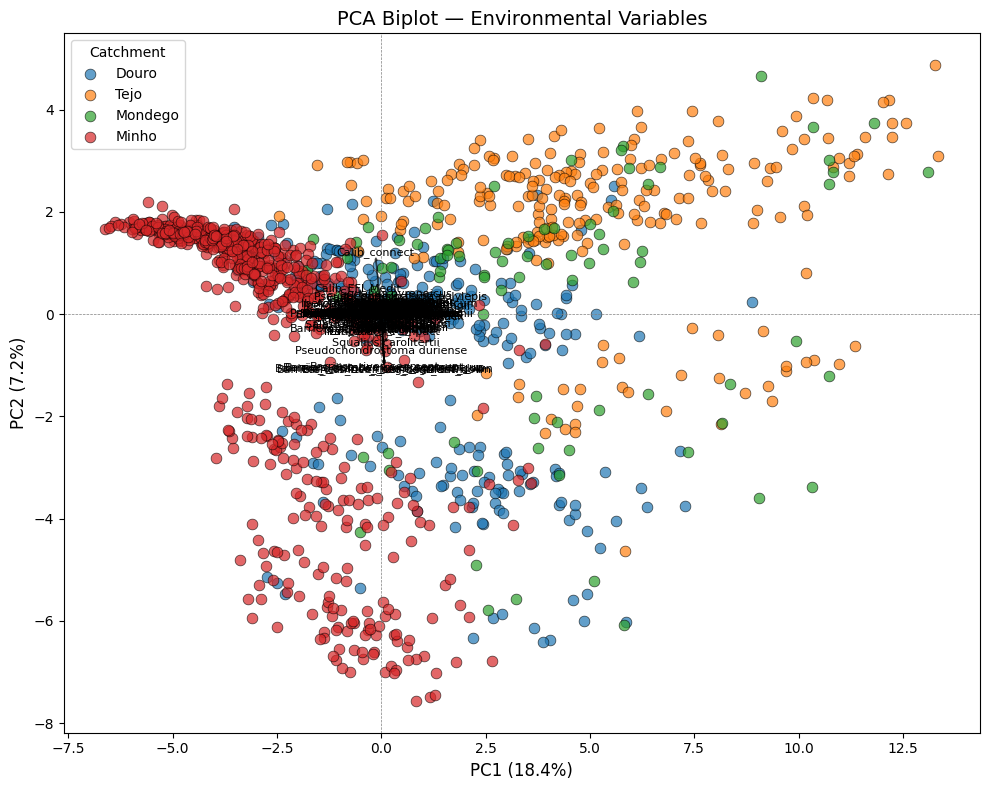

In [8]:
# --- Run PCA ---
pca = PCA()
scores = pca.fit_transform(X_scaled)

var_explained = pca.explained_variance_ratio_ * 100
print(f"PC1: {var_explained[0]:.1f}%  |  PC2: {var_explained[1]:.1f}%")

# --- Color map for basins ---
colors = {'Douro': '#1f77b4', 'Tejo': '#ff7f0e', 'Mondego': '#2ca02c', 'Minho': '#d62728'}

fig, ax = plt.subplots(figsize=(10, 8))

# Plot site scores
for basin in basins:
    mask = groups == basin
    ax.scatter(scores[mask, 0], scores[mask, 1],
               label=basin, color=colors[basin], alpha=0.7, s=60, edgecolors='k', linewidths=0.5)

# Plot variable loadings
loadings = pca.components_.T  # shape: (n_vars, n_components)
scale = 3  # scale arrows for visibility

for i, var in enumerate(env_vars):
    ax.arrow(0, 0,
             loadings[i, 0] * scale,
             loadings[i, 1] * scale,
             head_width=0.05, head_length=0.05,
             fc='black', ec='black', alpha=0.6)
    ax.text(loadings[i, 0] * scale * 1.15,
            loadings[i, 1] * scale * 1.15,
            var, fontsize=8, ha='center', va='center', color='black')

ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')
ax.set_xlabel(f'PC1 ({var_explained[0]:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({var_explained[1]:.1f}%)', fontsize=12)
ax.set_title('PCA Biplot — Environmental Variables', fontsize=14)
ax.legend(title='Catchment', fontsize=10)
plt.tight_layout()
plt.savefig('PCA_biplot.png', dpi=150)

##PROMPT: Run a PCoA and plot the sites on the first two axes colored by catchment name.

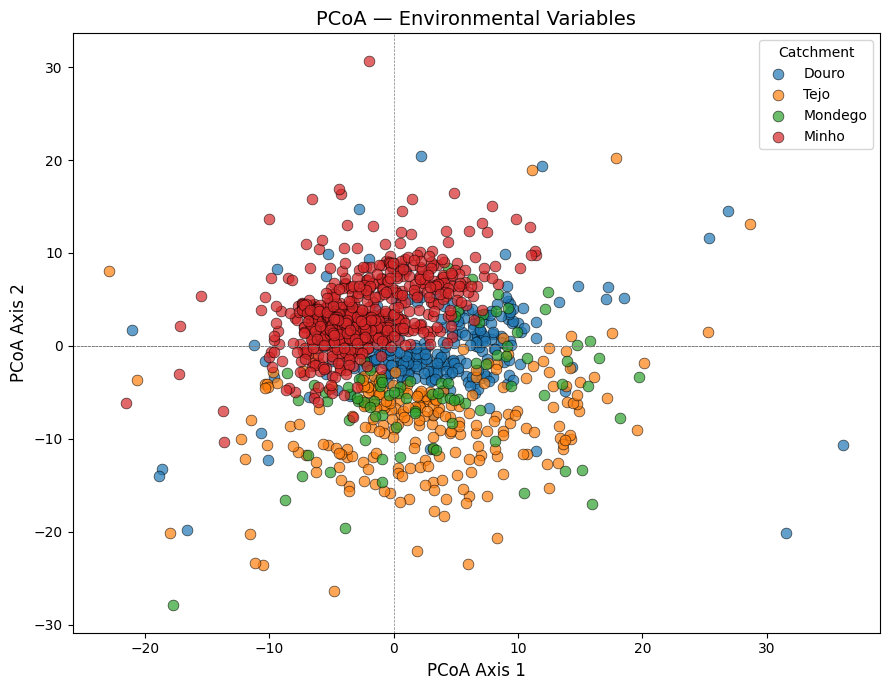

In [9]:
# --- Run PCoA (Classical MDS on Euclidean distances) ---
from sklearn.manifold import MDS

dist_matrix = squareform(pdist(X_scaled, metric='euclidean'))

mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
pcoa_scores = mds.fit_transform(dist_matrix)

fig, ax = plt.subplots(figsize=(9, 7))

for basin in basins:
    mask = (groups == basin).values
    ax.scatter(pcoa_scores[mask, 0], pcoa_scores[mask, 1],
               label=basin, color=colors[basin], alpha=0.7, s=60, edgecolors='k', linewidths=0.5)
    ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')
ax.set_xlabel('PCoA Axis 1', fontsize=12)
ax.set_ylabel('PCoA Axis 2', fontsize=12)
ax.set_title('PCoA — Environmental Variables', fontsize=14)
ax.legend(title='Catchment', fontsize=10)
plt.tight_layout()
plt.savefig('PCoA_plot.png', dpi=150)
plt.show()

##PROMPT: run an LDA using catchment name as the grouping variable and make a biplot with site scores and variable arrows on LD1 and LD2, colored by catchment name.

LD1: 76.3%  |  LD2: 14.4%


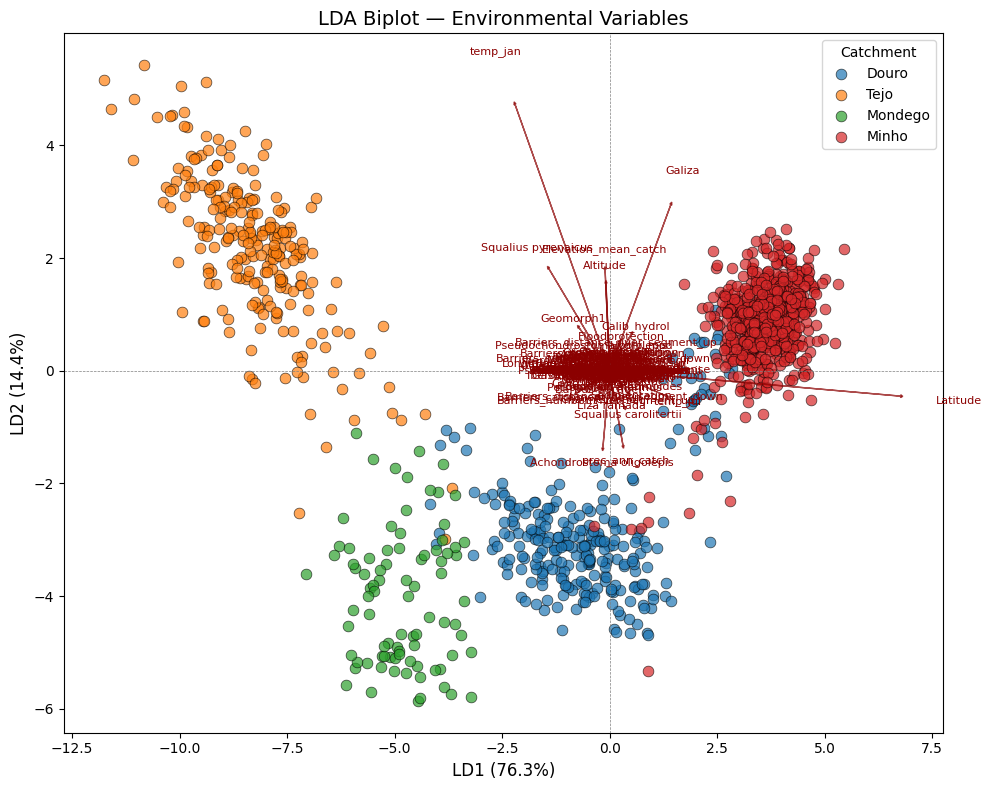

In [10]:
# --- Run LDA ---
lda = LinearDiscriminantAnalysis()
lda_scores = lda.fit_transform(X_scaled, groups)

# Variance explained by each discriminant axis
explained = lda.explained_variance_ratio_ * 100
print(f"LD1: {explained[0]:.1f}%  |  LD2: {explained[1]:.1f}%")

fig, ax = plt.subplots(figsize=(10, 8))

# Plot site scores
for basin in basins:
    mask = (groups == basin).values
    ax.scatter(lda_scores[mask, 0], lda_scores[mask, 1],
               label=basin, color=colors[basin], alpha=0.7, s=60, edgecolors='k', linewidths=0.5)

# Plot LDA loadings (structure coefficients)
lda_loadings = lda.scalings_  # shape: (n_features, n_components)
scale = 2

for i, var in enumerate(env_vars):
    ax.arrow(0, 0,
             lda_loadings[i, 0] * scale,
             lda_loadings[i, 1] * scale,
             head_width=0.05, head_length=0.05,
             fc='darkred', ec='darkred', alpha=0.7)
    ax.text(lda_loadings[i, 0] * scale * 1.2,
            lda_loadings[i, 1] * scale * 1.2,
            var, fontsize=8, ha='center', va='center', color='darkred')

ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')
ax.set_xlabel(f'LD1 ({explained[0]:.1f}%)', fontsize=12)
ax.set_ylabel(f'LD2 ({explained[1]:.1f}%)', fontsize=12)
ax.set_title('LDA Biplot — Environmental Variables', fontsize=14)
ax.legend(title='Catchment', fontsize=10)
plt.tight_layout()
plt.savefig('LDA_biplot.png', dpi=150)
plt.show()
